# 00 — Dataset audit

Before applying signal processing, feature extraction, or machine learning methods, we need to understand the dataset.

In this notebook, we will audit the ESC-50 subset prepared for this class.

The goal is to answer basic but important questions:

1. How many audio files do we have?
2. How many sound classes are represented?
3. Is the dataset balanced?
4. Are all audio files available on disk?
5. Are there missing values in the metadata?
6. Are there duplicated filenames?
7. What are the sampling rates and durations of the audio files?

A dataset audit is an essentialb step in audio data mining. Many errors come not from the model, but from problems in the dataset organization, labels, metadata, or file paths.

In [9]:
# Imports
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [10]:
# Paths
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUBSET_METADATA = PROJECT_ROOT / "data" / "processed" / "esc50_subset" / "esc50_subset_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA)
print("Metadata exists:", SUBSET_METADATA.exists())

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Metadata exists: True


In [11]:
# Loads
metadata = pd.read_csv(SUBSET_METADATA)

print("Number of rows:", len(metadata))
print("Number of columns:", metadata.shape[1])

metadata.head()

Number of rows: 80
Number of columns: 8


,filename,fold,target,category,esc10,src_file,take,subset_audio_path
0,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,data/processed/esc50_subset/audio/1-100038-A-1...
1,1-34495-A-14.wav,1,14,chirping_birds,False,34495,A,data/processed/esc50_subset/audio/1-34495-A-14...
2,1-34497-A-14.wav,1,14,chirping_birds,False,34497,A,data/processed/esc50_subset/audio/1-34497-A-14...
3,1-38559-A-14.wav,1,14,chirping_birds,False,38559,A,data/processed/esc50_subset/audio/1-38559-A-14...
4,1-38560-A-14.wav,1,14,chirping_birds,False,38560,A,data/processed/esc50_subset/audio/1-38560-A-14...


In [12]:
# Summary
print("Dataset summary")
print("-" * 40)

print("Number of audio files:", len(metadata))
print("Number of metadata columns:", metadata.shape[1])
print("Number of classes:", metadata["category"].nunique())
print("Number of folds:", metadata["fold"].nunique())

print("\nColumns:")
for column in metadata.columns:
    print("-", column)

Dataset summary
----------------------------------------
Number of audio files: 80
Number of metadata columns: 8
Number of classes: 8
Number of folds: 2

Columns:
- filename
- fold
- target
- category
- esc10
- src_file
- take
- subset_audio_path


In [13]:
# Data types
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   filename           80 non-null     str  
 1   fold               80 non-null     int64
 2   target             80 non-null     int64
 3   category           80 non-null     str  
 4   esc10              80 non-null     bool 
 5   src_file           80 non-null     int64
 6   take               80 non-null     str  
 7   subset_audio_path  80 non-null     str  
dtypes: bool(1), int64(3), str(4)
memory usage: 4.6 KB


In [15]:
# Missing values
missing_values = metadata.isna().sum()

if missing_values.sum() == 0:
    print("No missing values found in the metadata.")
else:
    print("Missing values found:")
    print(missing_values[missing_values > 0])


No missing values found in the metadata.


In [16]:
# Available classes
classes = sorted(metadata["category"].unique())

print("Available classes:")
for class_name in classes:
    print("-", class_name)

Available classes:
- chirping_birds
- clock_tick
- dog
- helicopter
- keyboard_typing
- rain
- sea_waves
- sneezing


In [17]:
# Class distributions
class_counts = metadata["category"].value_counts().sort_index()

class_counts

category
chirping_birds     10
clock_tick         10
dog                10
helicopter         10
keyboard_typing    10
rain               10
sea_waves          10
sneezing           10
Name: count, dtype: int64

In [18]:
# Disk file verification
metadata["file_exists"] = metadata["subset_audio_path"].apply(
    lambda path: (PROJECT_ROOT / path).exists()
)

print("Files available:", metadata["file_exists"].sum())
print("Files missing:", (~metadata["file_exists"]).sum())

metadata[metadata["file_exists"] == False]

Files available: 80
Files missing: 0


,filename,fold,target,category,esc10,src_file,take,subset_audio_path,file_exists


In [19]:
# Check for duplicate names
duplicated_filenames = metadata["filename"].duplicated().sum()

print("Duplicated filenames:", duplicated_filenames)

Duplicated filenames: 0


In [20]:
## Inspect audio duration and sampling rate
audio_audit_rows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Auditing audio files"):
    audio_path = PROJECT_ROOT / row["subset_audio_path"]

    y_tmp, sr_tmp = librosa.load(audio_path, sr=None, mono=True)
    duration_tmp = librosa.get_duration(y=y_tmp, sr=sr_tmp)

    audio_audit_rows.append({
        "filename": row["filename"],
        "category": row["category"],
        "sampling_rate": sr_tmp,
        "n_samples": len(y_tmp),
        "duration": duration_tmp,
        "min_amplitude": y_tmp.min(),
        "max_amplitude": y_tmp.max(),
    })

audio_audit = pd.DataFrame(audio_audit_rows)

audio_audit.head()

Auditing audio files: 100%|██████████| 80/80 [00:01<00:00, 65.39it/s]


,filename,category,sampling_rate,n_samples,duration,min_amplitude,max_amplitude
0,1-100038-A-14.wav,chirping_birds,44100,220500,5.0,-0.480499,0.545563
1,1-34495-A-14.wav,chirping_birds,44100,220500,5.0,-0.594421,0.594299
2,1-34497-A-14.wav,chirping_birds,44100,220500,5.0,-0.171448,0.162750
3,1-38559-A-14.wav,chirping_birds,44100,220500,5.0,-0.080658,0.088135
4,1-38560-A-14.wav,chirping_birds,44100,220500,5.0,-0.094604,0.086975


In [21]:
# Duration and sampling rate summary
audio_audit[["duration", "sampling_rate", "n_samples", "min_amplitude", "max_amplitude"]].describe()

,duration,sampling_rate,n_samples,min_amplitude,max_amplitude
count,80.0,80.0,80.0,80.000000,80.000000
mean,5.0,44100.0,220500.0,-0.608416,0.611752
std,0.0,0.0,0.0,0.300990,0.300806
min,5.0,44100.0,220500.0,-1.000000,0.084351
25%,5.0,44100.0,220500.0,-0.892967,0.355804
50%,5.0,44100.0,220500.0,-0.677536,0.670197
75%,5.0,44100.0,220500.0,-0.396729,0.876656
max,5.0,44100.0,220500.0,-0.077515,0.999969


In [22]:
print("Sampling rates found:")
print(audio_audit["sampling_rate"].value_counts())

print("\nDuration summary by class:")
audio_audit.groupby("category")["duration"].describe()

Sampling rates found:
sampling_rate
44100    80
Name: count, dtype: int64

Duration summary by class:


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
chirping_birds,10.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0
clock_tick,10.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0
dog,10.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0
helicopter,10.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0
keyboard_typing,10.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0
rain,10.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0
sea_waves,10.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0
sneezing,10.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0


<Figure size 1000x400 with 0 Axes>

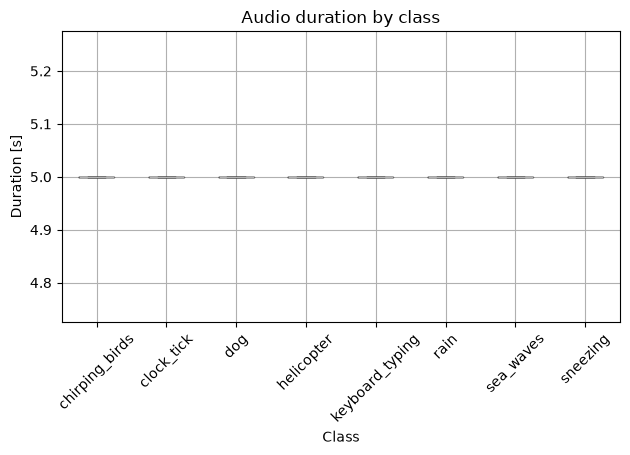

In [24]:
## Audio duration distribution by class
plt.figure(figsize=(10, 4))
audio_audit.boxplot(column="duration", by="category", rot=45)
plt.title("Audio duration by class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Duration [s]")
plt.tight_layout()
plt.show()

### Interpretation

The duration plot shows that all audio files in the selected ESC-50 subset have a duration of approximately 5 seconds.

This is useful because it means that the dataset is consistent in terms of audio length. Therefore, differences observed later in the waveform, spectrograms, or extracted features are more likely to be related to the sound content rather than to differences in file duration.

In [25]:
audio_audit.groupby("category")["duration"].agg(["min", "max", "mean", "std"])

,min,max,mean,std
category,,,,
chirping_birds,5.0,5.0,5.0,0.0
clock_tick,5.0,5.0,5.0,0.0
dog,5.0,5.0,5.0,0.0
helicopter,5.0,5.0,5.0,0.0
keyboard_typing,5.0,5.0,5.0,0.0
rain,5.0,5.0,5.0,0.0
sea_waves,5.0,5.0,5.0,0.0
sneezing,5.0,5.0,5.0,0.0


## Dataset audit summary

From this audit, we verified that:

- The subset contains 80 audio files.
- The subset contains 8 sound classes.
- The class distribution is balanced: 10 files per class.
- All referenced audio files are available on disk.
- There are no missing values in the metadata.
- There are no duplicated filenames.
- The audio files have consistent durations.
- The sampling rates were inspected before applying signal processing.

This gives us confidence to continue with waveform visualization, time-frequency analysis, feature extraction, and audio classification.